#### Projeto de estudo em análise de dados utilizando Python.

O objetivo é praticar a manipulação de dados, o tratamento de inconsistências, a estatística descritiva e a análise exploratória.



In [1077]:
# Importações
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

# Importa o módulo 'stats', da biblioteca SciPy, que será utilizado para obter valores estatísticos
from scipy import stats

# Importa a função chi2_contingency da biblioteca SciPy, especificamente do módulo de estatística
# chi2_contingency executa o teste do qui-quadrado de independência, que verifica se existe relação entre duas variáveis categóricas
from scipy.stats import chi2_contingency

# Importa a biblioteca sqlite3, que permite a conexão e a manipulação de banco de dados SQLite no Python
import sqlite3

In [1078]:
# Leitura da base de dados
dados = pd.read_excel('../data/dados-1.xlsx')

#### Exploração inicial da base de dados

In [1079]:
# O parâmetro dentro dos parenteses diz a quantidade de linhas a serem exibidas
dados.head(10) 

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
3,3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Automotivo,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Sênior,de R$ 12.001/mês a R$ 16.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,15463.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
6,6,zytlxsdgalh22cgrijvzytlxa49i8yzx,21.0,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,4491.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
8,8,zy4o5dk6iuxpdwgzy4o58xvd6ykwohrj,33.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Sênior,de R$ 6.001/mês a R$ 8.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,7112.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0


In [1080]:
# São exibidas as últimas linhas da tabela
dados.tail()

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4266,4266,01jnrn9f6va0menfhk2ztm01jnrn96bp,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Tecnologia/Fábrica de Software,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,de 7 a 10 anos,4329.0
4267,4267,01dyfxam4u4bi29fem01dyfxaq9akvqp,30.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3758.0
4268,4268,00zw9ks9d40z4u00zz3d20iix65qpli3,29.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,Setor Imobiliário/ Construção Civil,de 101 a 500,1.0,Gerente/Head,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,19607.0
4269,4269,00xu7yujd7s57emj00xu7y0c3njix3de,NaN,17-21,Masculino,Branca,Não,NaN,NaN,True,...,Indústria,de 1.001 a 3.000,0.0,NaN,Outra Opção,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,989.0
4270,4270,00lb35llmdsidpa00lb35qcdysnzvhv7,24.0,22-24,Masculino,Branca,Não,NaN,NaN,True,...,Agronegócios,de 501 a 1.000,0.0,NaN,Analista de Dados/Data Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,3079.0


In [1081]:
# Aqui não são necessários parâmetros, pois o shape é um atributo (acessa informação já pronta)
# e mostra a quantidade de linhas e de colunas (x, y)
dados.shape

(4271, 28)

In [1082]:
# Forma alternativa de encontrar o número de linhas
len(dados) 

4271

In [1083]:
# Forma de encontrar o nome de todas as colunas
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO'],
      dtype='object')

In [1084]:
# Mostra um resumo da estrutura do DataFrame:
# nomes das colunas, tipos de dados e quantidade de valores não nulos (identifica dados faltantes)
dados.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Data columns (total 28 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   Unnamed: 0                                                                                                                 4271 non-null   int64  
 1   ID                                                                                                                         4271 non-null   object 
 2   IDADE                                                                                                                      4197 non-null   float64
 3   FAIXA IDADE                                                                                                                4271 

#### Tipos de Dados:
- qualitativos: descrevem características ou qualidades, não números e não são usados para cálculos (ex: cor, gênero, estado civil)
- quantitativos: representam valores numéricos e podem ser usados em operações matemáticas (ex: idade, salário, altura) e dividem-se em discretos/inteiros (ex: número de filhos) e em contínuos/decimais (ex: altura)
- categóricos: são um tipo de dados qualitativo, organizados em categorias e dividem-se em nominais/sem ordem (ex: cor, cidade) e em ordinais/com ordem (ex: baixo, médio, alto)

In [1085]:
# Método que retorna colunas com valores numéricos
dados.describe()

,Unnamed: 0,IDADE,MUDOU DE ESTADO?,GESTOR?,SALARIO
count,4271.000000,4197.000000,4171.000000,3694.000000,3694.000000
mean,2135.000000,31.169168,0.806281,0.193016,10969.266919
std,1233.075829,6.902803,0.395258,0.394719,19419.753189
min,0.000000,18.000000,0.000000,0.000000,35.000000
25%,1067.500000,26.000000,1.000000,0.000000,4269.500000
50%,2135.000000,30.000000,1.000000,0.000000,7625.500000
75%,3202.500000,35.000000,1.000000,0.000000,12778.500000
max,4270.000000,54.000000,1.000000,1.000000,485191.000000


In [1086]:
# Filtra tudo que for "Feminino"
dados[dados['GENERO'] == 'Feminino'] 

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0
10,10,zwy34gktg0tfjq2ttjvazwy34gg3g49i,25.0,25-29,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,de 101 a 500,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,3450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,4248,070o4zayoboztox764qu070o4zafbqrd,27.0,25-29,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 101 a 500,0.0,NaN,Cientista de Dados/Data Scientist,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,4781.0
4251,4251,068hhicrqggu068huq0l2ab3g7liagy8,34.0,30-34,Feminino,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5673.0
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4259,4259,03n2lq8st9zobnowu3w03n2lqi0flz2w,28.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...","Relação com outros membros da empresa, em mome...",True,...,Finanças ou Bancos,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,24963.0


In [1087]:
# Filtra tudo que não for 'Masculino', ou seja, inclui nulos, que não se declaram etc, e não traz nenhum gênero masculino
dados[dados['GENERO'] != 'Masculino'] 

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0
10,10,zwy34gktg0tfjq2ttjvazwy34gg3g49i,25.0,25-29,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Varejo,de 101 a 500,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 3.001/mês a R$ 4.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,3450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4248,4248,070o4zayoboztox764qu070o4zafbqrd,27.0,25-29,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 101 a 500,0.0,NaN,Cientista de Dados/Data Scientist,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,4781.0
4251,4251,068hhicrqggu068huq0l2ab3g7liagy8,34.0,30-34,Feminino,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Pleno,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5673.0
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4259,4259,03n2lq8st9zobnowu3w03n2lqi0flz2w,28.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...","Relação com outros membros da empresa, em mome...",True,...,Finanças ou Bancos,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,24963.0


In [1088]:
# Filtra o DataFrame 'dados', retornando apenas as linhas em que a coluna 'GENERO' contém a palavra 'não'
# Ignorando valores nulos com na=False
dados[dados['GENERO'].str.contains('não', na=False)] 

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
562,562,vhuw8xnpbmj6oh20xovhuwcbdl4a12ni,29.0,25-29,Prefiro não informar,Parda,Não,"Sim, acredito que a minha a experiência profis...",Atenção dada pelas pessoas diante das minhas o...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1528,1528,n2ktdn33istvlu1ha4v3kn2ktdn1rsp1,NaN,55+,Prefiro não informar,Indígena,Prefiro não informar,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 51 a 100,0.0,NaN,Analista de Suporte/Analista Técnico,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Menos de 1 ano,826.0
1913,1913,k3as6jdh3w4jf4ztsw4kpkk3as6jdy19,30.0,30-34,Prefiro não informar,Prefiro não informar,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Outra Opção,de 101 a 500,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,de 3 a 4 anos,11476.0
1925,1925,jzppdwep2kpisqjjzppdh304v83cj7eu,NaN,17-21,Prefiro não informar,Prefiro não informar,Prefiro não informar,"Sim, acredito que minha experiência profission...",Quantidade de oportunidades de emprego/vagas r...,False,...,Setor Farmaceutico,de 1 a 5,0.0,NaN,Outra Opção,Júnior,de R$ 2.001/mês a R$ 3.000/mês,de 1 a 2 anos,Menos de 1 ano,2294.0
2554,2554,f5l206z0hr9uh3nz2iiff5l206c0g10o,20.0,17-21,Prefiro não informar,Prefiro não informar,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,Cientista de Dados/Data Scientist,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,de 1 a 2 anos,1339.0
3090,3090,a6ugmsw7s8hu5aa6uglio5apj74fam9o,26.0,25-29,Prefiro não informar,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,de 101 a 500,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,11545.0
3357,3357,7q0icczxn0l3a894cbx7q0icczjyud0n,29.0,25-29,Prefiro não informar,Preta,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 1.001 a 3.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Júnior,de R$ 6.001/mês a R$ 8.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,6345.0
3493,3493,6m8haop6lxnaizpwij6m8haopiax98jg,25.0,25-29,Prefiro não informar,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 3.001/mês a R$ 4.000/mês,de 3 a 4 anos,Menos de 1 ano,3900.0
3610,3610,5mloglozmr0r715mntaxbt6xy8b5olmb,30.0,30-34,Prefiro não informar,Branca,Não,"Sim, acredito que a minha a experiência profis...",Velocidade de progressão de carreira,True,...,Tecnologia/Fábrica de Software,de 101 a 500,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 8.001/mês a R$ 12.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...,10174.0
4171,4171,0rksyxnqhn13nwytwi6y0rkssx6jmodf,26.0,25-29,Prefiro não informar,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Outra Opção,de 1.001 a 3.000,0.0,NaN,Analista de Dados/Data Analyst,Pleno,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,Menos de 1 ano,10517.0


In [1089]:
# Filtra idades acima de 30 anos
dados[dados['IDADE'] > 30]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
2,2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 12.001/mês a R$ 16.000/mês,de 3 a 4 anos,Mais de 10 anos,14202.0
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4257,4257,043snvbsxn3fuyfe043j5comuyu8g6ba,46.0,45-49,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,1.0,Gerente/Head,NaN,NaN,Acima de R$ 40.001/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,62001.0
4260,4260,03atvow8404tatt2iixjds03atvownkz,36.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4261,4261,02xomoejng6c9152kde02xomww412qpg,33.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4262,4262,02vlm03c29g3fcys8tj06102vlm0983h,31.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,de 3 a 4 anos,18402.0


In [1090]:
# Filtra idades acima de 30 anos e gênero feminino
dados[(dados['IDADE'] > 30) & (dados['GENERO'] == 'Feminino')]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
4,4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,de 101 a 500,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Pleno,de R$ 6.001/mês a R$ 8.000/mês,Não tenho experiência na área de dados,Mais de 10 anos,7733.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
7,7,zyc0twzno2sm5or5ovoxzyc0twz0300d,31.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 6 a 10,0.0,NaN,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 2.001/mês a R$ 3.000/mês,Menos de 1 ano,Menos de 1 ano,2704.0
14,14,zwez49k0jhdvfkfst4zwef137uuf4ivy,35.0,35-39,Feminino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Atenção dada pelas pessoas diante das minhas o...,True,...,Varejo,Acima de 3.000,0.0,NaN,Analista de Negócios/Business Analyst,Pleno,de R$ 6.001/mês a R$ 8.000/mês,de 1 a 2 anos,Não tive experiência na área de TI/Engenharia ...,7416.0
23,23,zuqfcwtl9unfc5ezuqfcwm8coytsp5ap,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,0.0,NaN,Engenheiro de Dados/Arquiteto de Dados/Data En...,Sênior,de R$ 12.001/mês a R$ 16.000/mês,Mais de 10 anos,de 5 a 6 anos,13418.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4214,4214,0gprow0ownrbfneftxf0gprow4kyrqdy,41.0,40-44,Feminino,Branca,Prefiro não informar,"Sim, acredito que a minha a experiência profis...","Oportunidades de progressão de carreira, Veloc...",True,...,Seguros ou Previdência,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 8.001/mês a R$ 12.000/mês,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,11452.0
4221,4221,0fgi5bnb0u9b0fgc0jmqlbnvtu12b76d,34.0,30-34,Feminino,Outra,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Área de Consultoria,de 51 a 100,0.0,NaN,Outra Opção,Júnior,de R$ 4.001/mês a R$ 6.000/mês,Menos de 1 ano,Menos de 1 ano,5687.0
4240,4240,0a5xgxb1ljmuqn0un8a10a5xg4eufs2l,37.0,35-39,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Finanças ou Bancos,de 51 a 100,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,Menos de 1 ano,1182.0
4247,4247,07qzabp4ujpe4oz81udmb07qzabp4h0t,34.0,30-34,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor de Energia,de 11 a 50,0.0,NaN,Cientista de Dados/Data Scientist,Júnior,de R$ 4.001/mês a R$ 6.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,5925.0


In [1091]:
# Filtra pessoas que NÃO são 'Branca' OU que possuem nível de ensino superior
dados[(dados['COR/RACA/ETNIA'] != 'Branca') | (dados['NIVEL DE ENSINO'].str.contains('Superior', na=False))]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
0,0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Setor Público,Acima de 3.000,0.0,NaN,DBA/Administrador de Banco de Dados,Júnior,de R$ 8.001/mês a R$ 12.000/mês,de 1 a 2 anos,de 7 a 10 anos,11194.0
1,1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,Outra Opção,Acima de 3.000,1.0,Supervisor/Coordenador,NaN,NaN,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Menos de 1 ano,4695.0
5,5,zz0nlhbd8oxyiyxzz0nlh7g4xkiaza5v,32.0,30-34,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 2.001/mês a R$ 3.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,2336.0
6,6,zytlxsdgalh22cgrijvzytlxa49i8yzx,21.0,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,0.0,NaN,Analista de BI/BI Analyst,Júnior,de R$ 4.001/mês a R$ 6.000/mês,de 1 a 2 anos,Menos de 1 ano,4491.0
9,9,zxc3d314cn1c2ovmzxc34ha7nkw1na3j,NaN,55+,Feminino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Educação,Acima de 3.000,0.0,NaN,Professor,Pleno,de R$ 8.001/mês a R$ 12.000/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,10822.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4256,4256,04gb9ekqsw14vtkr5rpux04gb9evsfgq,28.0,25-29,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,de 501 a 1.000,0.0,NaN,Analista de Negócios/Business Analyst,Pleno,de R$ 4.001/mês a R$ 6.000/mês,de 3 a 4 anos,Não tive experiência na área de TI/Engenharia ...,4137.0
4257,4257,043snvbsxn3fuyfe043j5comuyu8g6ba,46.0,45-49,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Finanças ou Bancos,Acima de 3.000,1.0,Gerente/Head,NaN,NaN,Acima de R$ 40.001/mês,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,62001.0
4260,4260,03atvow8404tatt2iixjds03atvownkz,36.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4262,4262,02vlm03c29g3fcys8tj06102vlm0983h,31.0,30-34,Masculino,Amarela,Não,Não acredito que minha experiência profissiona...,NaN,True,...,Tecnologia/Fábrica de Software,de 501 a 1.000,1.0,Team Leader/Tech Leader,NaN,NaN,de R$ 16.001/mês a R$ 20.000/mês,de 3 a 4 anos,de 3 a 4 anos,18402.0


In [1092]:
# Ignora valores nulos (padrão)
dados['GENERO'].nunique()

3

In [1093]:
# Inclui valores nulos na contagem
dados['GENERO'].nunique(dropna=False)

4

In [1094]:
# Ver quais são os valores únicos (não só a quantidade)
dados['GENERO'].unique()

array(['Masculino', 'Feminino', nan, 'Prefiro não informar'], dtype=object)

In [1095]:
# Ver frequência de cada valor (mais analítico)
dados['GENERO'].value_counts()

GENERO
Masculino               3194
Feminino                1056
Prefiro não informar      12
Name: count, dtype: int64

In [1096]:
# Ver frequência de cada valor (mais analítico)
dados['COR/RACA/ETNIA'].value_counts()

COR/RACA/ETNIA
Branca                  2744
Parda                   1054
Preta                    291
Amarela                  128
Prefiro não informar      26
Outra                     17
Indígena                  11
Name: count, dtype: int64

In [1097]:
# Filtra registros onde a cor/raça/etnia não é 'Branca'
# e calcula quantos tipos distintos de cor/raça existem em cada nível de ensino
dados[dados['COR/RACA/ETNIA'] != 'Branca'].groupby('NIVEL DE ENSINO')['COR/RACA/ETNIA'].nunique()

NIVEL DE ENSINO
Doutorado ou Phd              4
Estudante de Graduação        5
Graduação/Bacharelado         6
Mestrado                      6
Não tenho graduação formal    4
Prefiro não informar          2
Pós-graduação                 6
Name: COR/RACA/ETNIA, dtype: int64

In [1098]:
# Remove registros com cor/raça/etnia nula e agrupa os dados
# por nível de ensino e cor/raça/etnia, contando a frequência de cada combinação
dados.dropna(subset=['COR/RACA/ETNIA']).groupby(['NIVEL DE ENSINO', 'COR/RACA/ETNIA']).size()

NIVEL DE ENSINO             COR/RACA/ETNIA      
Doutorado ou Phd            Amarela                   7
                            Branca                  127
                            Parda                    50
                            Prefiro não informar      1
                            Preta                     6
Estudante de Graduação      Amarela                  15
                            Branca                  365
                            Indígena                  2
                            Parda                   178
                            Prefiro não informar      2
                            Preta                    51
Graduação/Bacharelado       Amarela                  50
                            Branca                  999
                            Indígena                  4
                            Outra                     6
                            Parda                   333
                            Prefiro não informar     14

In [1099]:
# Remove registros com gênero nulo e agrupa por nível de ensino e gênero,
# contando quantas ocorrências existem em cada combinação
dados.dropna(subset=['GENERO']).groupby(['NIVEL DE ENSINO', 'GENERO']).size()

NIVEL DE ENSINO             GENERO              
Doutorado ou Phd            Feminino                  57
                            Masculino                134
Estudante de Graduação      Feminino                 104
                            Masculino                506
                            Prefiro não informar       1
Graduação/Bacharelado       Feminino                 365
                            Masculino               1138
                            Prefiro não informar       4
Mestrado                    Feminino                 133
                            Masculino                386
                            Prefiro não informar       1
Não tenho graduação formal  Feminino                  24
                            Masculino                 86
Prefiro não informar        Feminino                   3
                            Masculino                  8
                            Prefiro não informar       1
Pós-graduação               Feminino   

In [1100]:
# Conta quantos registros possuem 'Amarela' na coluna 'COR/RACA/ETNIA', ignorando valores nulos
print(dados[dados['COR/RACA/ETNIA'].str.contains('Amarela', na=False)].shape[0], 'registros possuem cor/raça/etnia "Amarela"')

128 registros possuem cor/raça/etnia "Amarela"


In [1101]:
# Conta quantos registros possuem idade abaixo de 40 anos na coluna 'IDADE', ignorando valores nulos
print(dados[dados['IDADE'] < 40].shape[0], 'registros possuem idade abaixo de 40 anos')

3686 registros possuem idade abaixo de 40 anos


In [1102]:
# Conta quantas pessoas são 'Amarela' e têm menos de 40 anos
print(dados[(dados['COR/RACA/ETNIA'].str.contains('Amarela', na=False)) &
 (dados['IDADE'] < 40)].shape[0], 'registros são de pessoas que se declararam amarelas e têm idade abaixo de 40 anos')

101 registros são de pessoas que se declararam amarelas e têm idade abaixo de 40 anos


#### Regra geral

( ) -> Como agrupar -> Define por qual coluna você vai agrupar os dados

[ ] -> O que analisar dentro do grupo -> Define qual coluna será analisada após o agrupamento

In [1103]:
# Agrupa os dados pela coluna 'GENERO' e conta quantos IDs únicos existem em cada grupo
# Feminino: 1055 IDs únicos
# Masculino: 3194 IDs únicos
# Prefiro não informar: 12 IDs únicos
dados.groupby('GENERO')['ID'].nunique()

GENERO
Feminino                1055
Masculino               3194
Prefiro não informar      12
Name: ID, dtype: int64

In [1104]:
# Agrupa os dados pela coluna 'GENERO' e conta quantos IDs únicos existem em cada grupo, incluindo os nulos
# dropna, por padrão, é 'True'; logo, quando é para mostrar NaN, usa-se 'False'
dados.groupby('GENERO', dropna=False)['ID'].nunique()

GENERO
Feminino                1055
Masculino               3194
Prefiro não informar      12
NaN                        9
Name: ID, dtype: int64

In [1105]:
# Mostra se há ID duplicado
dados['ID'].duplicated().sum()

1

In [1106]:
# Mostra todas as linhas onde o ID se repete
# É importante identificar qual a linha que se repete, pois ID é chave única e deve ser única em toda a tabela
dados[dados['ID'].duplicated(keep=False)]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
375,375,x4w2zctsfwfqh3q8aphgx4w2zflx9d1u,49.0,45-49,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Área da Saúde,de 501 a 1.000,1.0,Gerente/Head,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,Mais de 10 anos,Mais de 10 anos,24545.0
376,376,x4w2zctsfwfqh3q8aphgx4w2zflx9d1u,49.0,45-49,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,Área da Saúde,de 501 a 1.000,1.0,Gerente/Head,NaN,NaN,de R$ 20.001/mês a R$ 25.000/mês,Mais de 10 anos,Mais de 10 anos,24938.0


#### Insight importante:

.nunique() → Remove duplicados antes de contar

.count() ou .size() → Contam tudo (inclusive repetidos)

In [1107]:
dados[dados['IDADE'] > 30]['NIVEL'].value_counts()

NIVEL
Sênior    525
Pleno     408
Júnior    274
Name: count, dtype: int64

In [1108]:
dados[(dados['IDADE'] > 30) & (dados['GENERO'] == 'Feminino')]['NIVEL'].value_counts()

NIVEL
Pleno     117
Sênior    114
Júnior     96
Name: count, dtype: int64

In [1109]:
# Cria uma tabela dinâmica, com Pandas, que conta quantos IDs existem para cada combinação de gênero e se é gestor ou não
# 0.0 quer dizer que não são gestores e 1.0 que são
pd.pivot_table(dados, values=['ID'], index=['GENERO'], columns=['GESTOR?'], aggfunc='count')

ID     
GESTOR?                0.0  1.0
GENERO                         
Feminino               754  132
Masculino             2212  578
Prefiro não informar     9    2

#### Estatística Básica

In [1110]:
lista_idades = [26, 30, 32, 22, 26, 35, 40, 20, 43, 31, 23]

In [1111]:
# Como calcular a soma das idades
np.sum(lista_idades)

328

In [1112]:
# Como saber a quantidade total de idades
len(lista_idades)

11

In [1113]:
# Como calcular a média das idades: Média é o resultado de somar todos os valores e dividir pela quantidade de valores
media = np.sum(lista_idades) / len(lista_idades)
print('A média das idades é de', media)

A média das idades é de 29.818181818181817


In [1114]:
# Outra alternativa para calcular a média das idades
np.sum(lista_idades)/len(lista_idades)

29.818181818181817

In [1115]:
# Forma mais simples usando função np.mean, que é a forma ideal, pois calcula a média automaticamente
media = np.mean(lista_idades)
print('A média aritmética das idades é de', media)

A média aritmética das idades é de 29.818181818181817


In [1116]:
# Para ordenar os valores contidos na lista_idades, usa-se o .sort()
# A mediana é o valor exatamente no meio. Por exemplo: na lista ordenada abaixo, é o número 30 (tem 5 números à direita e 5 à esquerda)
lista_idades.sort()
print("A lista de idades ordenada é:", lista_idades)

A lista de idades ordenada é: [20, 22, 23, 26, 26, 30, 31, 32, 35, 40, 43]


In [1117]:
# Nova lista de idades com a idade 100
lista_idades = [26, 30, 32, 22, 26, 35, 40, 20, 43, 31, 23, 100]

In [1118]:
# Lista de idades atualizada com a idade 100 e novamente ordenada para usar como parâmetro para a mediana calculada abaixo
lista_idades.sort()
print("A lista de idades ordenada é:", lista_idades)

A lista de idades ordenada é: [20, 22, 23, 26, 26, 30, 31, 32, 35, 40, 43, 100]


In [1119]:
# Mediana é o valor que fica no meio de um conjunto de dados ordenado, ou seja, divide os dados em duas partes iguais (50% para cada lado)
# Para calcular a mediana, pega-se os números centrais (30 e 31) e faz a média entre eles
# A mediana é usada quando há valores muito altos/baixos (outliers) e quer representar melhor o comportamento "típico"
mediana = np.median(lista_idades)
print('A mediana das novas idades é de', mediana)

A mediana das novas idades é de 30.5


#### Retornando à tabela

In [1120]:
media = dados['IDADE'].mean()
print('A média de idade das pessoas cadastradas na tabela é de', media)

A média de idade das pessoas cadastradas na tabela é de 31.169168453657374


In [1121]:
mediana = dados['IDADE'].median()
print('A mediana das idades das pessoas cadastradas na tabela é de', mediana)

A mediana das idades das pessoas cadastradas na tabela é de 30.0


In [1122]:
# mode() retorna o valor mais frequente, mas retorna uma Series (índice 0, valor frequente 27.0, nome da coluna Name: IDADE e tipo de dado dtype: float64)
# O número 27, que é a idade mais frequente cadastrada, está dentro de uma estrutura (Series)
repeticao = dados['IDADE'].mode()
print('A idade mais frequente na tabela é', repeticao)

A idade mais frequente na tabela é 0    27.0
Name: IDADE, dtype: float64


In [1123]:
# Para um mode() mais limpo
# .mode() returma uma Series, que pode conter várias "modas" (frequências), então o [0] acessa o primeiro valor dessa Series, que é a moda mais repetida
repeticao = dados['IDADE'].mode()[0]
print('A idade mais frequente na tabela é', repeticao)

A idade mais frequente na tabela é 27.0


In [1124]:
# Desvio padrão: mede o quanto os dados estão próximos ou distantes da média
# Se estão baixos, os dados são consistentes | Se estão altos, os dados são variáveis e/ou instáveis
# O desvio padrão de 7 em uma análise de dados é um valor alto
desvio = dados['IDADE'].std()
print('O desvio padrão das idades cadastradas é de', desvio)

O desvio padrão das idades cadastradas é de 6.902802832143122


In [1125]:
# O coeficiente de variação (cv) mostra o nível de dispersão dos dados em relação à média
# Permite avaliar, de forma proporcional, se a variação é baixa, moderada ou alta
# cv ≈ 0.22 (22%): indica variabilidade moderada, ou seja, os dados possuem dispersão razoável em torno da média
cv = dados['IDADE'].std() / dados['IDADE'].mean()
print('O coeficiente de variação é de', cv)

O coeficiente de variação é de 0.2214625277028573


In [1126]:
# A função .min() percorre todos os valores da coluna 'IDADE' e retorna o menor deles
minimo = dados['IDADE'].min()
print('A idade mínima cadastrada na tabela é', minimo, 'anos')

A idade mínima cadastrada na tabela é 18.0 anos


In [1127]:
# A função .max() percorre todos os valores da coluna 'IDADE' e retorna o maior deles
maximo = dados['IDADE'].max()
print('A idade máxima cadastrada na tabela é', maximo, )

A idade máxima cadastrada na tabela é 54.0


In [1128]:
# dados['GENERO'] == 'Feminino' filtra o dataset para considerar apenas registros do gênero feminino
# Depois, ['IDADE'].mean() calcula a média da coluna 'IDADE', permitindo analisar o perfil etário desse grupo
media_idade_feminino = dados[dados['GENERO'] == 'Feminino']['IDADE'].mean()
print('A média de idade de pessoas do gênero feminino é de', media_idade_feminino, 'anos')

A média de idade de pessoas do gênero feminino é de 31.318051575931232 anos


In [1129]:
# É calculada a média de idade de quem respondeu ser do gênero masculino
media_idade_masculino = dados[dados['GENERO'] == 'Masculino']['IDADE'].mean()
print('A média de idade de pessoas do gênero masculino é de', media_idade_masculino, 'anos')

A média de idade de pessoas do gênero masculino é de 31.147876077930373 anos


In [1130]:
# É calculada a média de salário de pessoas do gênero feminino
media_salario_feminino = dados[dados['GENERO'] == 'Feminino']['SALARIO'].mean()
print('A média de salário de pessoas do gênero feminino é de R$', media_salario_feminino)

A média de salário de pessoas do gênero feminino é de R$ 8673.22460496614


In [1131]:
# É calculada a média de salário de pessoas do gênero masculino
media_salario_masculino = dados[dados['GENERO'] == 'Masculino']['SALARIO'].mean()
print('A média de salário de pessoas do gênero masculino é de R$', media_salario_masculino)

A média de salário de pessoas do gênero masculino é de R$ 11724.552688172043


#### Valores Faltantes

In [1132]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4271 entries, 0 to 4270
Data columns (total 28 columns):
 #   Column                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                     --------------  -----  
 0   Unnamed: 0                                                                                                                 4271 non-null   int64  
 1   ID                                                                                                                         4271 non-null   object 
 2   IDADE                                                                                                                      4197 non-null   float64
 3   FAIXA IDADE                                                                                                                4271 

#### Trabalhando coluna 'GENERO'

In [1133]:
# Agrupa-se por 'GENERO', considerando também valores ausentes (NaN) e contabiliza IDs únicos
# Isso permite identificar e quantificar os dados faltantes na base para posterior tratamento
dados.groupby('GENERO', dropna = False)['ID'].nunique()

GENERO
Feminino                1055
Masculino               3194
Prefiro não informar      12
NaN                        9
Name: ID, dtype: int64

In [1134]:
# dados['GENERO'] = é dizer: substitui a coluna 'GENERO' antiga por essa nova versão corrigida
# Em suma: pega a coluna 'GENERO', preencha os valores vazios com 'Prefiro não informar' e atualize a tabela
dados['GENERO'] = dados['GENERO'].fillna('Prefiro não informar')

In [1135]:
# Dados atualizados após o preenchimento dos valores vazios
dados.groupby('GENERO', dropna = False)['ID'].nunique()

GENERO
Feminino                1055
Masculino               3194
Prefiro não informar      21
Name: ID, dtype: int64

#### Trabalhando a coluna 'IDADE'

In [1136]:
# Quantos valores estão vazios (NaN) e quantos estão preenchidos na coluna 'IDADE'
# .isnull() verifica linha por linha (vazio = True / valor = False)
# .value_counts() conta quantas vezes cada valor aparece (ex: False = 3 / True = 1)
dados['IDADE'].isnull().value_counts()

IDADE
False    4197
True       74
Name: count, dtype: int64

In [1137]:
# dados[dados['IDADE'].isnull()]: quero apenas as linhas onde a coluna 'IDADE' esteja vazia
# dados['IDADE'].isnull() cria um filtro: idade vazia? True / idade preenchida? False
# ['FAIXA IDADE']: desse grupo filtrado acima, quero somente a coluna FAIXA IDADE
# .value_counts(): conta quantas pessoas existem em cada faixa
# Em suma: mostra, entre as pessoas que NÃO preencheram a coluna 'IDADE', quais são as faixas de idade delas
# Insight: pessoas mais velhas (55+) tendem a não preencher idade com mais frequência

dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()

FAIXA IDADE
55+      68
17-21     6
Name: count, dtype: int64

In [1138]:
# Filtra-se os registros da faixa etária 17-21 e calcula a média da coluna 'IDADE', permitindo analisar a idade média desse grupo específico
media_faixa_17_21 = dados[dados['FAIXA IDADE'] == '17-21']['IDADE'].mean()
print('A média da faixa de idade entre 17 e 21 anos é de', media_faixa_17_21)

A média da faixa de idade entre 17 e 21 anos é de 20.205479452054796


In [1139]:
# dados.loc[linhas, colunas]: seleciona linhas e colunas ao mesmo tempo
# (dados['FAIXA IDADE'] == '17-21'): filtra pessoas da faixa 17-21
# (dados['IDADE'].isnull()): filtra pessoas com idade vazia (NaN)
# Em suma, mostra a coluna 'IDADE' das pessoas que estão na faixa etária 17-21 e que NÃO preencheram a idade
dados.loc[(dados['FAIXA IDADE'] == '17-21') & (dados['IDADE'].isnull()), 'IDADE']


1925   NaN
2393   NaN
3367   NaN
4086   NaN
4177   NaN
4269   NaN
Name: IDADE, dtype: float64

In [1140]:
# Para preencher os dados vazios com a média da idade 17-21, basta atribuir ao dados.loc[...] a variável media_faixa_17_21
dados.loc[(dados['FAIXA IDADE'] == '17-21') & (dados['IDADE'].isnull()), 'IDADE'] = media_faixa_17_21

In [1141]:
# Após o tratamento dos valores nulos na coluna 'IDADE' (faixa 17-21), essa faixa deixa de aparecer no resultado, pois não há mais registros com idade ausente
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()

FAIXA IDADE
55+    68
Name: count, dtype: int64

In [1142]:
# Filtra-se os registros da faixa etária 55+ e calcula a média da coluna 'IDADE', permitindo analisar a idade média desse grupo específico
media_faixa_55 = dados[dados['FAIXA IDADE'] == '55+']['IDADE'].mean()
print('A média da faixa de idade 55+ anos é de', media_faixa_55)

A média da faixa de idade 55+ anos é de nan


In [1143]:
# Filtro sem .mean() para verificar o motivo pelo qual houve retorno NaN (todas as linhas de 55+ não foram preenchidas)
dados[dados['FAIXA IDADE'] == '55+']['IDADE']

9      NaN
66     NaN
96     NaN
121    NaN
156    NaN
        ..
4001   NaN
4043   NaN
4048   NaN
4061   NaN
4215   NaN
Name: IDADE, Length: 68, dtype: float64

In [1144]:
# Ao filtrar por 'NIVEL', também não é possível identificar motivo de tantos dados vazios na idade 55+
dados[dados['FAIXA IDADE'] == '55+']['NIVEL']

9        Pleno
66      Júnior
96       Pleno
121      Pleno
156     Júnior
         ...  
4001       NaN
4043       NaN
4048       NaN
4061       NaN
4215    Sênior
Name: NIVEL, Length: 68, dtype: object

In [1145]:
# Para que os demais dados não continuem vazios, é feita a média geral de idade, para substituir os valores nas respectivas linhas
media_geral_idade = dados['IDADE'].mean()
print('A média geral de idade é de', media_geral_idade, 'anos')

A média geral de idade é de 31.153517220250375 anos


In [1146]:
# Para preencher os dados vazios com a média geral de idade nos campos 55+, basta atribuir ao dados.loc[...] a variável media_geral_idade
dados.loc[(dados['FAIXA IDADE'] == '55+') & (dados['IDADE'].isnull()), 'IDADE'] = media_geral_idade

In [1147]:
# Após o tratamento dos dados nulos, não retorna nenhuma linha NaN
dados[dados['IDADE'].isnull()]['FAIXA IDADE'].value_counts()

Series([], Name: count, dtype: int64)

#### Tratanto coluna 'SALARIO'

In [1148]:
# Dentro do dataframe 'dados', os dados são filtrados pela coluna 'SALARIO', retornando apenas os registros onde NÃO há salário informado
dados[dados['SALARIO'].isnull()]

,Unnamed: 0,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,...,SETOR,NUMERO DE FUNCIONARIOS,GESTOR?,CARGO COMO GESTOR,CARGO ATUAL,NIVEL,FAIXA SALARIAL,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?,SALARIO
12,12,zwr9hqcpg513kaopenzwr9hibaqmldto,31.0,30-34,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,28,ztgepgj82o9oix0nztgepq2trcay6gpv,24.0,22-24,Feminino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,34,zsa9i6njd3e594mw0tvlk4zsa9iw86i9,24.0,22-24,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Quantidade de oportunidades de emprego/vagas r...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,39,zr4b2vm7dapp3linwqwn7zr4b2vmagqx,32.0,30-34,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,63,zm7o5yquakof0j6zm7vh3o0letznhdvh,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4242,4242,09oxwp6lsdwhw09ox1uobuxa8cq2pzma,26.0,25-29,Masculino,Branca,Não,NaN,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4252,4252,064pe9b1htw7mflhif064pe95dotv6yf,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4258,4258,03zjgijmnwv9qrlzbr03zjgij1eae1hw,25.0,25-29,Feminino,Branca,Não,"Sim, acredito que a minha a experiência profis...",Senioridade das vagas recebidas em relação à s...,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4260,4260,03atvow8404tatt2iixjds03atvownkz,36.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1149]:
# Quem não preencheu a coluna 'SALARIO' também não preencheu a coluna 'FAIXA SALARIAL'
dados[dados['SALARIO'].isnull()]['FAIXA SALARIAL'].value_counts()

Series([], Name: count, dtype: int64)

In [1150]:
# Usamos .median() para obter o valor central dos salários, pois costuma ter valores extremos (outliers)
mediana_salario = dados['SALARIO'].median()
print('A mediana de valor salarial é de R$', mediana_salario)

A mediana de valor salarial é de R$ 7625.5


In [1151]:
# Substitui valores nulos na coluna 'SALARIO' pela mediana, evitando perda de dados e distorções na análise
dados.loc[dados['SALARIO'].isnull(), 'SALARIO'] = mediana_salario

#### Valores Discrepantes (Outliers)

In [1152]:
lista_idades = [26, 30, 32, 22, 26, 35, 40, 20, 43, 31, 23]

In [1153]:
np.mean(lista_idades)

29.818181818181817

In [1154]:
lista_idades = [26, 30, 32, 22, 26, 35, 400, 20, 43, 31, 23]

In [1155]:
media = np.mean(lista_idades)
media

62.54545454545455

In [1156]:
# Desvio padrão (muito alto indica grande dispersão)
desvio = np.std(lista_idades)
desvio

106.89532997398872

In [1157]:
# Regra dos 3 desvios padrão
media + 3 * desvio

383.2314444674207

In [1158]:
# Regra dos 3 desvios padrão
media - 3 * desvio

-258.1405353765116

- Cálculo da média e desvio padrão para identificar outliers usando a regra de 3 desvios padrão.
- Valores fora do intervalo (média ± 3 * desvio) são considerados outliers.
- Observa-se que o valor 400 está fora desse intervalo, sendo um outlier que distorce as métricas.

{'whiskers': [<matplotlib.lines.Line2D at 0x231682c8b20>,
 'caps': [<matplotlib.lines.Line2D at 0x231682c9060>,
 'boxes': [<matplotlib.lines.Line2D at 0x231682c8880>],
 'medians': [<matplotlib.lines.Line2D at 0x231682c95a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x231682c9840>],
 'means': []}

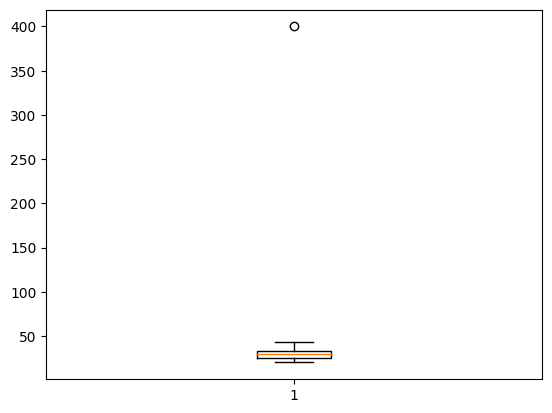

In [1159]:
plt.boxplot(lista_idades)

{'whiskers': [<matplotlib.lines.Line2D at 0x23165cb8a60>,
 'caps': [<matplotlib.lines.Line2D at 0x231682acd60>,
 'boxes': [<matplotlib.lines.Line2D at 0x231682ecf10>],
 'medians': [<matplotlib.lines.Line2D at 0x231682ad2a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x231682ad540>],
 'means': []}

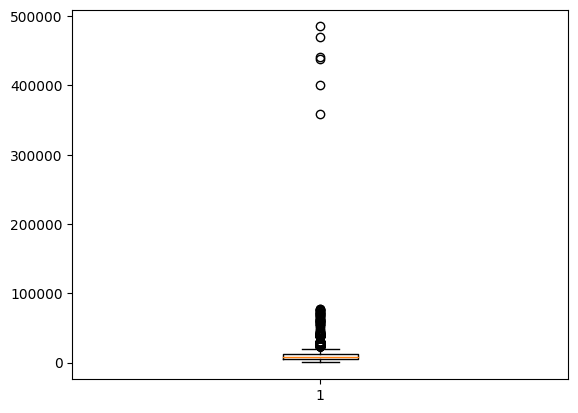

In [1160]:
plt.boxplot(dados['SALARIO'])

In [1161]:
# Quartis: dividem um conjunto ordenado de dados em 4 partes iguais
# Q1 (1º quartil): 25% dos dados = 20
# Q2 (2º quartil): 50% dos dados -> mediana = 30
# Q3 (3º quartil): 75% dos dados = 40

[10, 20, 30, 40, 50]

[10, 20, 30, 40, 50]

In [1162]:
Q1 = dados['SALARIO'].quantile(0.25)
print('O 1º quartil de SALARIO é', Q1)

O 1º quartil de SALARIO é 4751.5


In [1163]:
Q2 = dados['SALARIO'].quantile(0.50)
print('O 2º quartil de SALARIO é', Q2)

O 2º quartil de SALARIO é 7625.5


In [1164]:
Q3 = dados['SALARIO'].quantile(0.75)
print('O 3º quartil de SALARIO é', Q3)

O 3º quartil de SALARIO é 11794.5


In [1165]:
# Interquartil (IQR) é o intervalo central entre o 1º quartil e o 3º quartil, que não se confunde com o 2º quartil
IQR = Q3 - Q1
print('O interquartil é de', IQR)

O interquartil é de 7043.0


In [1166]:
# Calcular o limite inferior para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
print('O limite inferior é', limite_inferior)

O limite inferior é -5813.0


In [1167]:
# Calcular o limite superior para detectar outliers
limite_superior = Q3 + 1.5 * IQR
print('O limite superior é', limite_superior)

O limite superior é 22359.0


In [1168]:
dados['FAIXA SALARIAL'].value_counts()

FAIXA SALARIAL
de R$ 8.001/mês a R$ 12.000/mês     752
de R$ 4.001/mês a R$ 6.000/mês      584
de R$ 6.001/mês a R$ 8.000/mês      527
de R$ 12.001/mês a R$ 16.000/mês    437
de R$ 3.001/mês a R$ 4.000/mês      303
de R$ 2.001/mês a R$ 3.000/mês      285
de R$ 16.001/mês a R$ 20.000/mês    229
de R$ 1.001/mês a R$ 2.000/mês      216
de R$ 20.001/mês a R$ 25.000/mês    134
de R$ 25.001/mês a R$ 30.000/mês     77
de R$ 30.001/mês a R$ 40.000/mês     70
Acima de R$ 40.001/mês               45
Menos de R$ 1.000/mês                35
Name: count, dtype: int64

In [1169]:
# Calcula a média de salário
media_salario = dados['SALARIO'].mean()
print('A média de salário é de R$', media_salario)

A média de salário é de R$ 10517.53348162023


In [1170]:
# Calcula o desvio padrão de salário
desvio_salario = dados['SALARIO'].std()
print('O desvio padrão de salário é de R$', desvio_salario)

O desvio padrão de salário é de R$ 18096.21098911858


In [1171]:
# Calcula média e desvio padrão para estimar o limite superior usando a regra de 3 desvios padrão
# Valores acima desse limite podem ser considerados outliers (salários extremamente altos)
# Observa-se alta dispersão nos dados, indicando possível presença de valores extremos
limite_superior = media_salario + 3 * desvio_salario
print('O limite superior é de R$', limite_superior)

O limite superior é de R$ 64806.166448975964


In [1172]:
# Filtra os registros com salários ACIMA do limite superior (outliers)
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

FAIXA SALARIAL
Acima de R$ 40.001/mês              19
de R$ 30.001/mês a R$ 40.000/mês     3
Name: count, dtype: int64

In [1173]:
# Calcula a média dos salários da faixa de R$ 30.001/mês a R$ 40.000/mês, excluindo valores ACIMA do limite superior para evitar distorções causadas por outliers
media_salario_30_40 = dados[(dados['FAIXA SALARIAL'] == 'de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO'] < limite_superior)]['SALARIO'].mean()
print('A média dos salários da faixa de R$ 30.001/mês a R$ 40.000/mês é de R$', media_salario_30_40)

A média dos salários da faixa de R$ 30.001/mês a R$ 40.000/mês é de R$ 39002.19402985075


In [1174]:
# Substitui os salários considerados outliers dentro da faixa de R$ 30.001/mês a R$ 40.000/mês pela média da própria faixa (sem outliers)
dados.loc[(dados['FAIXA SALARIAL'] == 'de R$ 30.001/mês a R$ 40.000/mês') & (dados['SALARIO'] > limite_superior), 'SALARIO'] = media_salario_30_40

In [1175]:
# Validação após tratamento dos dados
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

FAIXA SALARIAL
Acima de R$ 40.001/mês    19
Name: count, dtype: int64

In [1176]:
# Filtra os registros com salários ACIMA do limite superior (outliers)
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

FAIXA SALARIAL
Acima de R$ 40.001/mês    19
Name: count, dtype: int64

In [1177]:
# Calcula a média dos salários da faixa acima de R$ 40.001/mês, excluindo valores ACIMA do limite superior para evitar distorções causadas por outliers
media_salario_40 = dados[(dados['FAIXA SALARIAL'] == 'Acima de R$ 40.001/mês') & (dados['SALARIO'] < limite_superior)]['SALARIO'].mean()
print('A média dos salários da faixa acima de R$ 40.001/mês	é de R$', media_salario_40)

A média dos salários da faixa acima de R$ 40.001/mês	é de R$ 53127.846153846156


In [1178]:
# Substitui os salários considerados outliers dentro da faixa acima de R$ 40.001/mês pela média da própria faixa (sem outliers)
dados.loc[(dados['FAIXA SALARIAL'] == 'Acima de R$ 40.001/mês') & (dados['SALARIO'] > limite_superior), 'SALARIO'] = media_salario_40

In [1179]:
# Validação após tratamento dos dados
dados[dados['SALARIO'] > limite_superior]['FAIXA SALARIAL'].value_counts()

Series([], Name: count, dtype: int64)

{'whiskers': [<matplotlib.lines.Line2D at 0x231682c4040>,
 'caps': [<matplotlib.lines.Line2D at 0x231682c4430>,
 'boxes': [<matplotlib.lines.Line2D at 0x23168257d60>],
 'medians': [<matplotlib.lines.Line2D at 0x231682c49a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x231682c4c40>],
 'means': []}

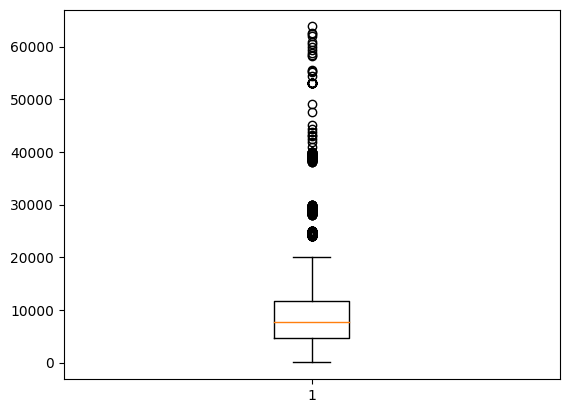

In [1180]:
plt.boxplot(dados['SALARIO'])

#### Distribuição Amostral e Intervalo de Confiança

In [1181]:
# Seleciona a coluna 'SALARIO' do dataframe, representando a amostra de salários
salarios = dados['SALARIO']
print(salarios)

0       11194.0
1        4695.0
2       14202.0
3       15463.0
4        7733.0
         ...   
4266     4329.0
4267     3758.0
4268    19607.0
4269      989.0
4270     3079.0
Name: SALARIO, Length: 4271, dtype: float64


In [1182]:
# Calcula a média dos salários da amostra, representando o valor médio observado
media_amostral = np.mean(salarios)
print(media_amostral)

9904.390109813306


In [1183]:
# Calcula o desvio padrão dos salários, indicando o nível de dispersão em torno da média
desvio_amostral = np.std(salarios)
print(desvio_amostral)

8306.104872579352


In [1184]:
# Define o nível de confiança da análise estatística (95%), indicando a probabilidade de o intervalo conter a média real
nivel_confianca = 0.95

In [1185]:
# Calcula o tamanho da amostra, ou seja, a quantidade de observações de salários
tamanho_amostra = len(salarios)
print(tamanho_amostra)

4271


In [1186]:
# Calcula o valor crítico (z-score) com base no nível de confiança definido (deixa o código mais profissional e flexível)
z = stats.norm.ppf((1 + nivel_confianca) / 2)
print(z)

1.959963984540054


In [1187]:
# Calcula o erro padrão da média utilizando a função 'sem' (standard error od the mean), que mede a variabilidade da média amostral em relação à média da população
erro_padrao = stats.sem(salarios)
print(erro_padrao)

127.11109872023638


In [1188]:
# Calcula o intervalo de confiança utilizando a distribuição 't' de Student, considerando o nível de confiança, grau de liberdade (n-1), média amostral (loc) e erro padrão (scale)
# Com 95% de confiança, a média salarial da população está dentro do intervalo calculado (9655.00 a 10153.00)
intervalo_confianca = stats.t.interval(nivel_confianca, tamanho_amostra-1, loc=media_amostral, scale=erro_padrao)
print(intervalo_confianca)

(9655.186295869078, 10153.593923757535)


#### Featuring Engineering

In [1189]:
# Função que cria uma regra de transformação de dados (featuring engineering)
# Há uma função com 2 parâmetros: gestor (1 = sim) e nível (nível atual da pessoa, exceto gestor)
# Se a pessoa for gestora ( == 1), redefine o nível como 'Pessoa Gestora'; caso contrário, mantém o nível original informado (ex: pleno, jr etc)

def preencher_nivel(gestor, nivel):
  if gestor == 1:
    return 'Pessoa Gestora'
  else:
    return nivel

In [1190]:
# Função que transforma linha a linha com lógica personalizada
# dados['NOVO NIVEL'] = : cria uma nova coluna chamada 'NOVO NIVEL' baseada em uma regra
# dados.apply(...) : aplica uma função em todas as linhas
# lambda x: : função anônima (sem nome), onde 'x' representa uma linha inteira
# x['GESTOR?'], x['NIVEL'] : pega os valores dessas colunas na linha atual
# preencher_nivel(...) : função que foi criada na linha de código acima (regra de negócio) / ex: é gestor? sim? retorna 'pessoa gestora'
# axis=1 : aplica a regra linha por linha (sem isso, aplicaria por coluna)

# Em resumo: aplica a função linha a linha para definir a nova coluna 'NOVO NIVEL', utilizando as colunas 'GESTOR?' e 'NIVEL' conforme regra da função preencher_nivel

dados['NOVO NIVEL'] = dados.apply(lambda x: preencher_nivel(x['GESTOR?'], x['NIVEL']), axis=1)

In [1191]:
dados['NOVO NIVEL'].value_counts()

NOVO NIVEL
Pleno             1060
Júnior            1023
Sênior             898
Pessoa Gestora     713
Name: count, dtype: int64

In [1192]:
dados['NIVEL']

0       Júnior
1          NaN
2        Pleno
3       Sênior
4        Pleno
         ...  
4266     Pleno
4267     Pleno
4268       NaN
4269    Júnior
4270    Júnior
Name: NIVEL, Length: 4271, dtype: object

In [1193]:
# Pré-processamento de dados: cria colunas com variáveis binárias (True / False) a partir da coluna 'NIVEL', mantendo a coluna original para não impactar análises anteriores
# dados = ... : atualiza o dataframe com a nova versão ('NIVEL_Junior' | 'NIVEL_Pleno' | 'NIVEL_Senior')

dummies_nivel = pd.get_dummies(dados['NIVEL'], prefix='NIVEL')
dados = pd.concat([dados, dummies_nivel], axis=1)

In [1194]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior'],
      dtype='object')

In [1195]:
# Classifica a geração com base na idade informada, considerando as faixas etárias em 2026 (o correto, segundo pesquisa em abril/2026)

def geracoes_2026(idade):
  if 46 <= idade <= 61:       # idades >= 46 & <= 61 anos correspondem à Geração X
    return 'Geração X'
  elif 30 <= idade <= 45:     # idades >= 30 & <= 45 anos correspondem à Geração Y/Millenial
    return 'Geração Y ou Millenial'
  elif 14 <= idade <= 29:     # idades >= 14 & <= 29 anos correspondem à é Geração Z
    return 'Geração Z'
  else:                       # idades fora dessas faixas (<= 13 & >= 62 anos) não se enquadram nos grupos definidos acima
    return 'Outra geração'

In [1196]:
# Verifica a existência de valores nulos (NaN) na coluna 'IDADE'
# Importante essa verificação, pois o código da linha seguinte pode dar erro
# Nesse caso, não há True e, portanto, não há valores nulos na coluna 'IDADE'

dados['IDADE'].isnull().value_counts()

IDADE
False    4271
Name: count, dtype: int64

In [1197]:
# Pega as idades em dados['IDADE'], aplica a função em cada linha (.apply(...)), classifica a idade (geracoes_2026) e salva o resultado com dados['GERACAO']
# Em resumo: aplica a função 'geracoes_2026' a cada valor da coluna 'IDADE', criando a nova coluna 'GERACAO' com a classificação geracional respectiva

dados['GERACAO2026'] = dados['IDADE'].apply(geracoes_2026)

In [1198]:
dados['GERACAO2026'].value_counts()

GERACAO2026
Geração Y ou Millenial    2079
Geração Z                 1999
Geração X                  193
Name: count, dtype: int64

In [1199]:
# Exemplo da aula

def determinar_geracao(idade):
  if 39 < idade <= 58:
    return 'Geração X'
  elif 29 < idade <= 39:
    return 'Millenial'
  elif 13 < idade <= 29:
    return 'Geração Z'
  else:
    return 'Outra geração'

In [1200]:
# Exemplo da aula

dados['GERACAO'] = dados['IDADE'].apply(determinar_geracao)

In [1201]:
# Exemplo da aula

dados['GERACAO'].value_counts()

GERACAO
Geração Z    1999
Millenial    1761
Geração X     511
Name: count, dtype: int64

In [1202]:
# Carrega a segunda base de dados que será utilizada para complementar o dataset principal

dados_parte2 = pd.read_excel('../data/dados-2.xlsx')

In [1203]:
dados_parte2.head()

,ID,Quanto tempo de experiência na área de dados você tem?,Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?,Você está satisfeito na sua empresa atual?,Qual o principal motivo da sua insatisfação com a empresa atual?,Você participou de entrevistas de emprego nos últimos 6 meses?,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,de 1 a 2 anos,de 7 a 10 anos,True,NaN,Não participei de entrevistas de emprego/proce...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL
1,zzls2oftfn9law393oezzls2ofhvfpzd,de 3 a 4 anos,Menos de 1 ano,False,Falta de oportunidade de crescimento no empreg...,"Sim, fiz entrevistas mas não fui aprovado",Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,de 3 a 4 anos,Mais de 10 anos,False,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,1
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,de 4 a 6 anos,Não tive experiência na área de TI/Engenharia ...,True,NaN,"Sim, fui aprovado e mudei de emprego","Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de...,0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,Não tenho experiência na área de dados,Mais de 10 anos,False,Falta de oportunidade de crescimento no empreg...,Não participei de entrevistas de emprego/proce...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL


In [1204]:
# Faz o merge entre o dataframe principal 'dados' e o dataframe 'dados_parte2', utilizando a coluna 'ID' como chave
# O tipo 'left' garante que todos os registros do dataframe original sejam mantidos, adicionando informações da segunda base quando houver correspondência

# Em resumo: leva os dados da outra planilha para a base principal, usando o ID como ligação

dados = dados.merge(dados_parte2, on='ID', how='left')

In [1205]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GERACAO2026', 'GERACAO',
       'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de d

In [1206]:
# Conta a frequência de cada resposta na coluna, permitindo visualizar quantas pessoas escolheram cada opção sobre a intenção (ou não) de mudar de emprego

dados['Você pretende mudar de emprego nos próximos 6 meses?'].value_counts()

Você pretende mudar de emprego nos próximos 6 meses?
Não estou buscando, mas me considero aberto a outras oportunidades         1354
Estou em busca de oportunidades dentro ou fora do Brasil                   1011
Não estou buscando e não pretendo mudar de emprego nos próximos 6 meses     978
Estou em busca de oportunidades, mas apenas fora do Brasil                  353
Name: count, dtype: int64

In [1207]:
# Cria coluna binária 'EM_BUSCA', classificando como True os registros cuja resposta contém a expressão 'em busca', indicando pessoas que estão procurando oportunidades

dados['EM_BUSCA'] = dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains('em busca', case=False)

In [1208]:
# Conta a quantidade de valores True e False na coluna 'EM_BUSCA'

dados['EM_BUSCA'].value_counts()

EM_BUSCA
False    2332
True     1364
Name: count, dtype: int64

In [1209]:
# Cria coluna binária 'ABERTO_OPORTUNIDADES', classificando como True os registros cuja resposta contém a expressão 'aberto', indicando pessoas que estão procurando oportunidades

dados['ABERTO_OPORTUNIDADES'] = dados['Você pretende mudar de emprego nos próximos 6 meses?'].str.contains('aberto', case=False)

In [1210]:
# Conta a quantidade de valores True e False na coluna 'ABERTO_OPORTUNIDADES'

dados['ABERTO_OPORTUNIDADES'].value_counts()

ABERTO_OPORTUNIDADES
False    2342
True     1354
Name: count, dtype: int64

In [1211]:
# Antes de definir categorias de 'COR/RACA/ETNIA', é importante verificar os valores reais com o código a seguir
# Conta a frequência de cada categoria da coluna 'COR/RACA/ETNIA', incluindo valores nulos (NaN)

dados['COR/RACA/ETNIA'].value_counts(dropna=False)

COR/RACA/ETNIA
Branca                  2746
Parda                   1054
Preta                    291
Amarela                  128
Prefiro não informar      26
Outra                     17
Indígena                  11
Name: count, dtype: int64

In [1212]:
# Cria coluna 'ETNIA' a partir da coluna original 'COR/RACA/ETNIA', agrupando categorias em 'Branca', 'Não branca' e 'Outras' para simplificar a análise
# Valores nulos também são tratados com pd.isnull(x) para que não haja falhas ou perdas na análise dedivdo a dados ausentes

dados['ETNIA'] = dados['COR/RACA/ETNIA'].apply(
    lambda x: 'Outras' if pd.isnull(x)
      else 'Branca' if x == 'Branca'
      else 'Não branca' if x in ['Preta', 'Parda', 'Amarela', 'Indígena']
      else 'Outras'
)

In [1213]:
# Conta a quantidade de valores para cada categoria

dados['ETNIA'].value_counts()

ETNIA
Branca        2746
Não branca    1484
Outras          43
Name: count, dtype: int64

### Correlação
- próximo de 1 -> relação positiva forte (quanto mais eu treino, mais forte eu fico)
- próximo de 0 -> pouca ou nenhuma relação
- próximo de -1 -> relação negativa forte (quanto mais fico em rede social, menos estudo)

In [1214]:
# Calcula o coeficiente de correlação (Pearson) entre as variáveis 'IDADE' e 'SALARIO', indicando a força e a direção da relação linear entre elas
# Pelos dados da planilha, o fator idade não é suficiente para fazer o salário aumentar (há uma pouca relação)

correlacao_continua = dados['IDADE'].corr(dados['SALARIO'])
print('A correlação contínua entre IDADE e SALARIO é de', correlacao_continua)

A correlação contínua entre IDADE e SALARIO é de 0.29024419686221


In [1215]:
# Gera uma tabela raca_ensino com a frequência entre 'COR/RACA/ETNIA' e 'NIVEL DE ENSINO'
# Os valores mostrados é a quantidade de ocorrências de cada combinação

tabela_raca_ensino = pd.crosstab(dados['COR/RACA/ETNIA'], dados['NIVEL DE ENSINO'])
tabela_raca_ensino

NIVEL DE ENSINO,Doutorado ou Phd,Estudante de Graduação,Graduação/Bacharelado,Mestrado,Não tenho graduação formal,Prefiro não informar,Pós-graduação
COR/RACA/ETNIA,,,,,,,
Amarela,7,15,50,14,2,0,40
Branca,127,365,999,355,65,8,827
Indígena,0,2,4,2,0,0,3
Outra,0,0,6,3,1,0,7
Parda,50,178,333,113,33,3,344
Prefiro não informar,1,2,14,1,0,1,7
Preta,6,51,104,33,9,0,88


In [1216]:
np.array(tabela_raca_ensino)

array([[  7,  15,  50,  14,   2,   0,  40],
       [127, 365, 999, 355,  65,   8, 827],
       [  0,   2,   4,   2,   0,   0,   3],
       [  0,   0,   6,   3,   1,   0,   7],
       [ 50, 178, 333, 113,  33,   3, 344],
       [  1,   2,  14,   1,   0,   1,   7],
       [  6,  51, 104,  33,   9,   0,  88]], dtype=int64)

In [1217]:
# O coeficiente de Cramér é uma métrica estatística usada para medir a força da associação entre duas variáveis categóricas
# É baseado no teste de qui-quadrado (x²) e o resultado varia de 0 a 1: 0 = não há associação / 1 = associação forte
# Ele responde: essas duas colunas categóricas têm alguma relação entre si?

def cramer_raca_ensino(coluna1, coluna2):                           # Define a função cramer_raca_ensino, que recebe duas colunas (colunas1 e coluna2)
  tabela_raca_ensino = np.array(pd.crosstab(coluna1, coluna2))      # Cria uma tabela de contigência (tabela_raca_ensino) entre as duas colunas, que mostra a frequência de cada combinação de categorias / np.array() transforma a tabela em um array do NumPy para facilitar o cálculo
  chi2 = chi2_contingency(tabela_raca_ensino)[0]                    # Calcula o qui-quadrado (x²) com base na tabela ratabela_raca_ensino / chi2_contingency() retorna mais de um resultado, e o [0] pega apenas o valor do estatístico qui-quadrado, que será usado na fórmula de Cramér
  soma = np.sum(tabela_raca_ensino)                                 # Soma todos os valores da tabela ratabela_raca_ensino (representa o total de observações analisadas)
  minimo = min(tabela_raca_ensino.shape) - 1                        # Pega a menor dimensão da tabela ratabela_raca_ensino (quantidade de linha ou colunas) e subtrai 1, que é usado para ajustar a fórmula do coeficiente de Cramér
  cramer = np.sqrt(chi2 / (soma * minimo))                          # Aplica a fórmula do coeficiente de Cramér, que é o cálcula da raiz quadrada para chegar ao valor final do coeficiente
  return cramer                                                     # Retorna o valor do coeficiente calculado

In [1218]:
# Com esse resultado próximo de 0, pode-se dizer que não há relação entre 'COR/RACA/ETNIA' e 'NIVEL DE ENSINO'
# Mas, na sociedade, sabemos que pessoas brancas têm níveis de ensino maiores do que às outras cores/raças/etnias
# Então, será que, em TI, esse dado tem relação com gênero?

cramer_raca_ensino(dados['COR/RACA/ETNIA'], dados['NIVEL DE ENSINO'])

0.04499106580480143

In [1219]:
# Para tirar a dúvida, uma tabela_genero_ensino com a frequência entre 'GENERO' e 'NIVEL DE ENSINO'
# Os valores mostrados é a quantidade de ocorrências de cada combinação

tabela_genero_ensino = pd.crosstab(dados['GENERO'], dados['NIVEL DE ENSINO'])
tabela_genero_ensino

NIVEL DE ENSINO,Doutorado ou Phd,Estudante de Graduação,Graduação/Bacharelado,Mestrado,Não tenho graduação formal,Prefiro não informar,Pós-graduação
GENERO,,,,,,,
Feminino,57,104,365,133,24,3,372
Masculino,134,506,1138,386,86,8,936
Prefiro não informar,0,3,7,2,0,1,8


In [1220]:
np.array(tabela_genero_ensino)

array([[  57,  104,  365,  133,   24,    3,  372],
       [ 134,  506, 1138,  386,   86,    8,  936],
       [   0,    3,    7,    2,    0,    1,    8]], dtype=int64)

In [1221]:
def cramer_genero_ensino(coluna1, coluna2):
  tabela_genero_ensino = np.array(pd.crosstab(coluna1, coluna2))
  chi2 = chi2_contingency(tabela_genero_ensino)[0]
  soma = np.sum(tabela_genero_ensino)
  minimo = min(tabela_genero_ensino.shape) - 1
  cramer = np.sqrt(chi2 / (soma * minimo))
  return cramer

In [1222]:
cramer_genero_ensino(dados['GENERO'], dados['NIVEL DE ENSINO'])

0.076119232802818

Raça x Ensino = resultado muito baixo / sem associação forte

Gênero x Ensino = resultado muito baixo / sem associação forte

Interpretação sociotécnica: estamos analisando pessoas que já estão na área de tecnologia e isso implica que já passaram por filtros (formação, acesso, oportunidade) e quem não conseguiu entrar na área não aparece no dataset. Resultado: diferenças estruturais podem exisitir, mas não aparecem como associação forte nesse recorte de dados analisados

In [1223]:
# Após o tratamento e análise dos dados, a base final foi exportada em formato CSV
dados.to_csv('../data/dados-tratados.csv', index=False)

#### Conectando o SQL com o Pandas

In [1224]:
# Faz a conexão com o banco de dados do SQLite
conexao = sqlite3.connect('../data/status_brasil.sqlite')

In [1225]:
# Cria uma consulta SQL para buscar todos os dados da tabela e encontrar o termo buscado
query = "SELECT * FROM Municipios_Brasileiros WHERE Cidade LIKE 'rio de janeiro'"

In [1226]:
# Executa a consulta SQL armazenada na variável 'query' e o resultado é carregado e visualizado
pd.read_sql(query, con=conexao)

,Cidade,Estado,Regiao,municipio_ID,pais
0,Rio De Janeiro,RJ,Sudeste,3656,Brasil


In [1227]:
# Faz a consulta e filtra os Estados desejados e calcula a média da renda por Estado
query = '''SELECT Municipios_Brasileiros.Estado, AVG(Municipio_Status.renda) FROM
        Municipios_Brasileiros INNER JOIN Municipio_Status ON 
        Municipios_Brasileiros.municipio_ID = Municipio_Status.municipio_ID
        GROUP BY Municipios_Brasileiros.Estado'''

In [1228]:
# Executa a consulta SQL armazenada na variável 'query' e o resultado é carregado e visualizado
pd.read_sql(query, con=conexao)

,Estado,AVG(Municipio_Status.renda)
0,AC,0.585455
1,AL,0.548363
2,AM,0.545113
3,AP,0.618875
4,BA,0.574805
5,CE,0.559293
6,DF,0.863000
7,ES,0.680628
8,GO,0.683980
9,MA,0.531664


In [1229]:
# Leitura da base de dados
dados = pd.read_excel('../data/dados-1.xlsx')

In [1230]:
# dados.columns para descobrir o nome da coluna que queremos sobre Estado onde mora
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO'],
      dtype='object')

In [1231]:
# Exibe os valores únicos da coluna 'UF ONDE MORA', sendo tudo transformado em lista
# A lista é armazenada na variável 'lista_estados'
lista_estados = list(dados['UF ONDE MORA'].unique())

In [1232]:
# Faz a consulta e filtra os Estados desejados e calcula a média da renda por Estado
query = '''SELECT Municipios_Brasileiros.Estado, AVG(Municipio_Status.renda) FROM
        Municipios_Brasileiros INNER JOIN Municipio_Status ON 
        Municipios_Brasileiros.municipio_ID = Municipio_Status.municipio_ID
        WHERE Municipios_Brasileiros.Estado IN ({})
        GROUP BY Municipios_Brasileiros.Estado'''.format(','.join(['?' for _ in lista_estados]))

In [1233]:
# Executa a consulta SQL armazenada na variável 'query' e o resultado é carregado e visualizado
pd.read_sql(query, con=conexao, params=lista_estados)

,Estado,AVG(Municipio_Status.renda)
0,AL,0.548363
1,AM,0.545113
2,BA,0.574805
3,CE,0.559293
4,DF,0.863000
5,ES,0.680628
6,GO,0.683980
7,MA,0.531664
8,MG,0.652008
9,MS,0.687846


In [1234]:
print(query)

SELECT Municipios_Brasileiros.Estado, AVG(Municipio_Status.renda) FROM
        Municipios_Brasileiros INNER JOIN Municipio_Status ON 
        Municipios_Brasileiros.municipio_ID = Municipio_Status.municipio_ID
        WHERE Municipios_Brasileiros.Estado IN (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)
        GROUP BY Municipios_Brasileiros.Estado


In [1235]:
# Executa a consulta SQL, aplica o filtro dos Estados, e armazena o resultado na variável 'estados_renda'
estados_renda = pd.read_sql(query, con=conexao, params=lista_estados)

In [1236]:
# Renomeia a coluna 'UF ONDE MORA' para 'Estado'
dados.rename(columns={'UF ONDE MORA' : 'Estado'}, inplace=True)

In [1237]:
# Exibe as colunas do dataframe
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'Estado', 'REGIAO ONDE MORA',
       'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO',
       'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO'],
      dtype='object')

In [1238]:
# Renomeia a coluna 'Estado' para 'ESTADO' no dataframe 'dados'
dados.rename(columns={'Estado': 'ESTADO'}, inplace=True)

# Renomeia a coluna 'Estado' para 'ESTADO' para ficar igual à do dataframe 'dados'
# A coluna 'Estado' no dataframe 'estados_renda' veio da query SQL SELECT Municipios_Brasileiros.Estado
estados_renda.rename(columns={'Estado': 'ESTADO'}, inplace=True)

# Renomeia a coluna 'AVG(Municipio_Status.renda)' para 'RENDA_MEDIA'
# A função 'AVG' calcula a média da renda dos municípios brasileiros
estados_renda.rename(columns={'AVG(Municipio_Status.renda)': 'RENDA_MEDIA'}, inplace=True)

In [1239]:
# Exibe as colunas do dataframe
dados.columns
estados_renda.columns

Index(['ESTADO', 'RENDA_MEDIA'], dtype='object')

In [1240]:
# Une os dataframes 'dados' e 'estados_renda, usando a coluna 'ESTADO'
# how='left' mantém todas as linhas do dataframe 'dados', mesmo que exista correspondência em 'estados_renda'
# As colunas de 'estados_renda' são adicionados ao dataframe original, trazendo, por exemplo, a média de renda de cada Estado
dados = dados.merge(estados_renda, on='ESTADO', how='left')

In [1241]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'ESTADO', 'REGIAO ONDE MORA',
       'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO',
       'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'RENDA_MEDIA'],
      dtype='object')

In [1242]:
# Remove colunas duplicadas da média de renda
# Essas colunas foram geradas durante testes e reexecuções do merge e deveria ser excluído,
# mas, para dar contexto ao notebook, mantive e adicionei 'ignore'
# errors='ignore' evita erro caso alguma coluna não exista mais
dados.drop(columns=[
        'AVG(Municipio_Status.renda)',
        'RENDA_MEDIA_x',
        'RENDA_MEDIA_y'
        ],
    inplace=True,
    errors='ignore'
)

In [1243]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'ESTADO', 'REGIAO ONDE MORA',
       'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO',
       'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'RENDA_MEDIA'],
      dtype='object')

In [1244]:
# Calcula a correlação entre o salário e a média de renda do Estado
correlacao_renda_salario = dados['SALARIO'].corr(dados['RENDA_MEDIA'])

In [1245]:
# Exibe o valor da correlação entre salário e renda média do estado
print('A correlação entre renda e salário é', correlacao_renda_salario)

A correlação entre renda e salário é 0.07248950401807608


In [1246]:
# Verifica a quantidade de valores nulos (NaN) nas colunas 'SALARIO' e 'RENDA_MEDIA'
dados[['SALARIO', 'RENDA_MEDIA']].isna().sum()

SALARIO        577
RENDA_MEDIA    115
dtype: int64

In [1247]:
# Remove as linhas com valores nulos e exibe a quantidade de linhas e colunas restantes
dados[['SALARIO', 'RENDA_MEDIA']].dropna().shape

(3603, 2)

In [1248]:
# Mostra a quantidade de valores nulos (NaN) em cada coluna
print(dados.isna().sum())

Unnamed: 0                                                                                                                      0
ID                                                                                                                              0
IDADE                                                                                                                          74
FAIXA IDADE                                                                                                                     0
GENERO                                                                                                                          9
COR/RACA/ETNIA                                                                                                                  0
PCD                                                                                                                             0
EXPERIENCIA_PROFISSIONAL_PREJUDICADA                                                      

In [1249]:
# Exibe somente as colunas que possuem valores nulos
print(dados.isna().sum()[dados.isna().sum() > 0])

IDADE                                                                                                                          74
GENERO                                                                                                                          9
EXPERIENCIA_PROFISSIONAL_PREJUDICADA                                                                                         2081
ASPECTOS_PREJUDICADOS                                                                                                        3434
ESTADO ONDE MORA                                                                                                              115
ESTADO                                                                                                                        115
REGIAO ONDE MORA                                                                                                              100
MUDOU DE ESTADO?                                                                          

In [1250]:
# Substitui NaN por "Não informado"
dados = dados.fillna("Não informado")

In [1251]:
print(dados.isna().sum().sum())

0


In [1252]:
# Mostra a quantidade de valores nulos na coluna GENERO
print(dados['GENERO'].isna().sum())

0


In [1253]:
# Mostra os valores da coluna GENERO, incluindo NaN
print(dados['GENERO'].value_counts(dropna=False))

GENERO
Masculino               3194
Feminino                1056
Prefiro não informar      12
Não informado              9
Name: count, dtype: int64


In [1254]:
# Troca "Não informado" por "Prefiro não informar"
dados['GENERO'] = dados['GENERO'].replace(
    'Não informado',
    'Prefiro não informar'
)

In [1255]:
print(dados['GENERO'].value_counts(dropna=False))

GENERO
Masculino               3194
Feminino                1056
Prefiro não informar      21
Name: count, dtype: int64


In [1256]:
# Verifica quantos valores existem em cada coluna
print(dados['ESTADO'].value_counts(dropna=False))

print("\n" + "="*50 + "\n")

print(dados['ESTADO ONDE MORA'].value_counts(dropna=False))

ESTADO
SP               1745
MG                478
RJ                338
PR                309
RS                204
BA                162
SC                156
DF                132
PE                120
Não informado     115
CE                 95
ES                 81
GO                 55
PB                 42
RN                 38
PA                 35
AL                 32
SE                 28
MA                 28
AM                 26
MT                 19
PI                 17
MS                 16
Name: count, dtype: int64


ESTADO ONDE MORA
São Paulo (SP)              1745
Minas Gerais (MG)            478
Rio de Janeiro (RJ)          338
Paraná (PR)                  309
Rio Grande do Sul (RS)       204
Bahia (BA)                   162
Santa Catarina (SC)          156
Distrito Federal (DF)        132
Pernambuco (PE)              120
Não informado                115
Ceará (CE)                    95
Espírito Santo (ES)           81
Goiás (GO)                    55
Paraíba (PB) 

In [1257]:
# Mostra linhas onde os valores são diferentes
diferencas = dados[
    dados['ESTADO'].fillna('') != dados['ESTADO ONDE MORA'].fillna('')
]

print(diferencas[['ESTADO', 'ESTADO ONDE MORA']])
print(f'Total de diferenças: {len(diferencas)}')

     ESTADO       ESTADO ONDE MORA
0        DF  Distrito Federal (DF)
1        PA              Pará (PA)
2        DF  Distrito Federal (DF)
3        MG      Minas Gerais (MG)
4        PA              Pará (PA)
...     ...                    ...
4266     SP         São Paulo (SP)
4267     MG      Minas Gerais (MG)
4268     SP         São Paulo (SP)
4269     SP         São Paulo (SP)
4270     GO             Goiás (GO)

[4156 rows x 2 columns]
Total de diferenças: 4156


In [1258]:
# Quantidade de NaN em cada coluna
print("ESTADO:", dados['ESTADO'].isna().sum())
print("ESTADO ONDE MORA:", dados['ESTADO ONDE MORA'].isna().sum())

ESTADO: 0
ESTADO ONDE MORA: 0


In [1259]:
# Remove a coluna ESTADO ONDE MORA, pois ela contém a mesma informação
# da coluna ESTADO, porém em formato descritivo
dados = dados.drop(columns=['ESTADO ONDE MORA'])

In [1260]:
dados.columns

Index(['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA',
       'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO', 'REGIAO ONDE MORA', 'MUDOU DE ESTADO?',
       'REGIAO DE ORIGEM', 'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'NIVEL', 'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'RENDA_MEDIA'],
      dtype='object')

In [1261]:
# Dicionário para converter siglas em nomes completos dos estados
mapa_estados = {
    'AC': 'Acre',
    'AL': 'Alagoas',
    'AP': 'Amapá',
    'AM': 'Amazonas',
    'BA': 'Bahia',
    'CE': 'Ceará',
    'DF': 'Distrito Federal',
    'ES': 'Espírito Santo',
    'GO': 'Goiás',
    'MA': 'Maranhão',
    'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul',
    'MG': 'Minas Gerais',
    'PA': 'Pará',
    'PB': 'Paraíba',
    'PR': 'Paraná',
    'PE': 'Pernambuco',
    'PI': 'Piauí',
    'RJ': 'Rio de Janeiro',
    'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul',
    'RO': 'Rondônia',
    'RR': 'Roraima',
    'SC': 'Santa Catarina',
    'SP': 'São Paulo',
    'SE': 'Sergipe',
    'TO': 'Tocantins'
}

# Cria a coluna ESTADO ONDE MORA com o nome completo do estado
dados['ESTADO ONDE MORA'] = dados['ESTADO'].map(mapa_estados)

In [1262]:
# Exibe as colunas ESTADO e ESTADO ONDE MORA lado a lado
print(dados[['ESTADO', 'ESTADO ONDE MORA']].head())

  ESTADO  ESTADO ONDE MORA
0     DF  Distrito Federal
1     PA              Pará
2     DF  Distrito Federal
3     MG      Minas Gerais
4     PA              Pará


In [1263]:
# Renomeia a coluna ESTADO para ESTADO (sigla)
dados = dados.rename(columns={'ESTADO': 'ESTADO (sigla)'})

In [1265]:
# Exibe as colunas ESTADO e ESTADO ONDE MORA lado a lado
print(dados[['ESTADO (sigla)', 'ESTADO ONDE MORA']].head())

  ESTADO (sigla)  ESTADO ONDE MORA
0             DF  Distrito Federal
1             PA              Pará
2             DF  Distrito Federal
3             MG      Minas Gerais
4             PA              Pará


In [1266]:
# Salva o dataframe tratado em um arquivo CSV
dados.to_csv('../data/dados-tratados.csv', index=False)